# Model Comparisons: Initial ST-GNN vs ConvLSTM vs Ex5 LSTM

This notebook compares the **initial ST-GNN model** (HUC12-level metrics from `stgnn_huc12_wise_metrics.csv`), **ConvLSTM**, and **Ex5 LSTM** (Montane, Maritime, Ephemeral) across the same basins. It loads precomputed metrics, aligns column names and scales, joins HUC8 names, and produces box plots and scatter plots by snow type and HUC8.

*Note: For time-split ST-GNN results and a common-HUC comparison, see `final_model_comparisons.ipynb`.*

## Imports

In [15]:
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from io import StringIO
from itertools import combinations
from scipy.stats import ttest_ind_from_stats

In [ ]:
s3 = boto3.client('s3')
bucket = "spatiotemporal-results"
key = "convlstm/convlstm_results.csv"

obj = s3.get_object(Bucket=bucket, Key=key)

## Step 1: Load data

Load initial ST-GNN metrics, ConvLSTM results, and Ex5 LSTM metrics (Montane, Maritime, Ephemeral); concatenate into `df_exp5`.

In [16]:
df_stgnn = pd.read_csv("stgnn_huc12_wise_metrics.csv")
df_convlstm = pd.read_csv(StringIO(obj['Body'].read().decode('utf-8')))
montane_df  = pd.read_csv("../../../../../notebooks/Ex5_DataIntegration/single_all_metrics_w_snow_types_and_elev_Montane.csv")
maritime_df  = pd.read_csv("../../../../../notebooks/Ex5_DataIntegration/single_all_metrics_w_snow_types_and_elev_Maritime_DI_mse.csv")
ephemeral_df  = pd.read_csv("../../../../../notebooks/Ex5_DataIntegration/single_all_metrics_w_snow_types_and_elev_Ephemeral_DI_mse.csv")
df_exp5 = pd.concat([montane_df, maritime_df, ephemeral_df], ignore_index=True)

Scale MSE (÷1e6) and rename columns so ST-GNN and ConvLSTM match LSTM naming (`Test KGE`, `Test MSE`, `Predominant_Snow`, `Huc_08`, `HUC_ID`).

In [17]:
df_stgnn['Test MSE'] = df_stgnn['mse']/1000000
df_stgnn = df_stgnn.rename(columns={
    'kge': 'Test KGE',
    'snow_type': 'Predominant_Snow',
    'huc8': 'Huc_08',
    'huc12': 'HUC_ID'
})
df_convlstm['Test MSE'] = df_convlstm['mse']/1000000
df_convlstm = df_convlstm.rename(columns={
    'kge': 'Test KGE',
    'snowtype': 'Predominant_Snow',
    'huc8_id': 'Huc_08',
    'huc12_id': 'HUC_ID'
})

Preview the first two rows of ConvLSTM, ST-GNN, and Ex5 LSTM DataFrames.

In [18]:
print(df_convlstm.head(2))
print(df_stgnn.head(2))
print(df_exp5.head(2))

         HUC_ID          mse    rmse_mm  Test KGE Predominant_Snow    Huc_08  \
0  170103020101  3229.549654  56.829127  0.856647   Montane Forest  17010302   
1  170103020102  2798.650342  52.902272  0.841030   Montane Forest  17010302   

   Test MSE  
0  0.003230  
1  0.002799  
         HUC_ID    Huc_08 Predominant_Snow  mean_elevation          mse  \
0  170200090101  17020009         Maritime     1758.266724  2558.550537   
1  170200090102  17020009         Maritime     1675.947876  5031.667480   

   Test KGE  mean_true_swe  mean_pred_swe  Test MSE  
0  0.976437      425.64040      435.17313  0.002559  
1  0.923982      426.70346      449.96606  0.005032  
         HUC_ID                                               Name  Test MSE  \
0  170103020101  Little North Fork South Fork Coeur d'Alene Riv...  0.020238   
1  170103020102  Canyon Creek-Upper South Fork Coeur d'Alene River  0.016541   

   Test KGE Predominant_Snow color_snow_type  mean_elevation    Huc_08  \
0  0.956158   

Load HUC8 ID–name mapping from S3 and merge into the comparison DataFrames for readable axis labels.

In [20]:
bucket = "snowml-shape"
key = "metadata/huc8_names_pnw.csv"

obj = s3.get_object(Bucket=bucket, Key=key)
df_names = pd.read_csv(StringIO(obj['Body'].read().decode('utf-8')))
df_names = df_names.rename(columns={
    'huc_id': 'Huc_08',
    'huc_name': 'Huc_08_nm'
})
df_names

,Huc_08,Huc_08_nm
0,17010302,South Fork Coeur d'Alene
1,17010304,St. Joe
2,17020009,Lake Chelan
3,17020010,Upper Columbia-Entiat
4,17020011,Wenatchee
5,17030001,Upper Yakima
6,17030002,Naches
7,17030003,Lower Yakima
8,17060207,Middle Salmon-Chamberlain
9,17060208,South Fork Salmon


Merge HUC8 names into ST-GNN and ConvLSTM DataFrames for plotting.

In [21]:
df_stgnn = df_stgnn.merge(
    df_names,
    on='Huc_08',
    how='left'
)
df_convlstm = df_convlstm.merge(
    df_names,
    on='Huc_08',
    how='left'
)

Summary by predominant snow type: HUC count, mean/std of Test MSE, and RMSE (mean/std).

In [22]:
#STGNN
df_stgnn.groupby("Predominant_Snow").agg(
    num_hucs=("HUC_ID", "count"),
    mse_mean=("Test MSE", "mean"),
    mse_std=("Test MSE", "std"),
    rmse_mean=("Test MSE", lambda x: np.sqrt(np.mean(x))),
    rmse_std=("Test MSE", lambda x: np.std(np.sqrt(x)))
).reset_index()

,Predominant_Snow,num_hucs,mse_mean,mse_std,rmse_mean,rmse_std
0,Boreal Forest,1,0.003823,NaN,0.061830,0.000000
1,Ephemeral,183,0.000296,0.000737,0.017209,0.011914
2,Maritime,157,0.004849,0.002968,0.069638,0.021097
3,Montane Forest,187,0.000835,0.000643,0.028896,0.010429
4,Prairie,11,0.000435,0.000402,0.020856,0.008997


In [23]:
#Conv-LSTM
df_convlstm.groupby("Predominant_Snow").agg(
    num_hucs=("HUC_ID", "count"),
    mse_mean=("Test MSE", "mean"),
    mse_std=("Test MSE", "std"),
    rmse_mean=("Test MSE", lambda x: np.sqrt(np.mean(x))),
    rmse_std=("Test MSE", lambda x: np.std(np.sqrt(x)))
).reset_index()

,Predominant_Snow,num_hucs,mse_mean,mse_std,rmse_mean,rmse_std
0,Boreal Forest,1,0.041705,NaN,0.204219,0.000000
1,Ephemeral,180,0.000903,0.003057,0.030051,0.021534
2,Maritime,154,0.071495,0.068633,0.267386,0.125462
3,Montane Forest,185,0.004564,0.007807,0.067560,0.037228
4,Prairie,11,0.002560,0.004293,0.050600,0.032342


In [24]:
#LSTM
df_exp5.groupby("Predominant_Snow").agg(
    num_hucs=("HUC_ID", "count"),
    mse_mean=("Test MSE", "mean"),
    mse_std=("Test MSE", "std"),
    rmse_mean=("Test MSE", lambda x: np.sqrt(np.mean(x))),
    rmse_std=("Test MSE", lambda x: np.std(np.sqrt(x)))
).reset_index()

,Predominant_Snow,num_hucs,mse_mean,mse_std,rmse_mean,rmse_std
0,Ephemeral,180,0.005392,0.006201,0.073428,0.036873
1,Maritime,154,0.043108,0.015834,0.207624,0.036538
2,Montane Forest,187,0.019084,0.007460,0.138146,0.026561


Model display names used in plot titles (ST-GNN, Conv-LSTM, LSTM).

In [25]:
STGNN = "ST-GNN"
CONV = "Conv-LSTM"
LSTM ="LSTM"

**extract_subdict:** helper to subset the snow-type color map for legends (e.g. Montane/Maritime/Ephemeral only).

In [26]:
def extract_subdict(original_dict, keys_to_extract):
    return {key: original_dict[key] for key in keys_to_extract if key in original_dict}

# Step 2 - Define Plotting And Analytics Functions 

**plot_boxplot_by_group:** boxplot of a metric (e.g. Test KGE) by group (snow type or HUC8), with optional colors and axis limits.

In [27]:
def plot_scatter(df, x_var_name, y_var_name, color_map, model_name, col, title="Scatter_Plot", save_local=False, show_legend=True, other=False,
                 min_val_y=None, max_val_y=None, tick_gap_y=None,
                 min_val_x=None, max_val_x=None, tick_gap_x=None):
    """
    Creates a scatter plot of specified x and y variables, colored by Predominant Snow Type.

    Parameters:
    - df: DataFrame containing the x and y variables and "color_snow_type" column.
    - x_var_name: Column name for the x-axis variable.
    - y_var_name: Column name for the y-axis variable.
    - color_map: Dictionary mapping labels to their respective colors for the legend.
    - title: Title of the plot (default: "Scatter Plot" with underscores).
    - save_local: If True, saves the plot as a PNG file.
    - show_legend: If True, shows the legend (default is True).
    """
    plt.figure(figsize=(8, 4))

    colors = df[col].map(color_map)
    colors = colors.fillna("gray")

    plt.scatter(df[x_var_name], df[y_var_name], c=colors, alpha=0.7, edgecolors="k")

    # Add labels and title
    plt.xlabel(x_var_name)
    plt.ylabel(y_var_name)
    plt.title(model_name+": "+title)
    if min_val_y is not None and max_val_y is not None:
        y_range = max_val_y - min_val_y
        y_pad = y_range * 0.05
        plt.ylim(min_val_y - y_pad, max_val_y + y_pad)
        plt.yticks(np.arange(min_val_y, max_val_y + tick_gap_y, tick_gap_y))

    if min_val_x is not None and max_val_x is not None:
        x_range = max_val_x - min_val_x
        x_pad = x_range * 0.05
        plt.xlim(min_val_x - x_pad, max_val_x + x_pad)
        plt.xticks(np.arange(min_val_x, max_val_x + tick_gap_x, tick_gap_x))

    plt.grid(
            True,
            which='major',
            axis='both',
            color='gray',
            linestyle='-',
            linewidth=0.4,
            alpha=0.15
        )
    # Show legend if show_legend is True
    if show_legend:
        handles = [plt.Line2D([0], [0], marker='o', color=color, markersize=8, label=label) 
               for label, color in color_map.items()]
        if other:
            handles.append(
                plt.Line2D([0], [0], marker='o', color="gray",
                           linestyle='None', markersize=8, label="Other")
            )
        plt.legend(handles=handles, title="Predominant Snow Type", loc='lower right', bbox_to_anchor=(0.95, 0.05))

    # Show or save plot
    if save_local:
        plt.savefig(f"charts/{title}.png", bbox_inches='tight')

    plt.show()


In [28]:
def plot_boxplot_by_group(df, parameter, title, groupby_column, model_name, color_map="tab20", category_order=None, trunc=False, save_local=False,
                        is_small=True,
                          min_val_y=None, max_val_y=None, tick_gap_y=None,
                          min_val_x=None, max_val_x=None, tick_gap_x=None):
    """
    Plot a boxplot for the given parameter grouped by a specified column.
    Parameters:
    - df: DataFrame containing the data.
    - parameter: The name of the parameter to be plotted (as a column in the DataFrame).
    - title: The title of the plot.
    - groupby_column: The column by which to group the data.
    - color_map: A dictionary mapping categories to colors. Defaults to None.
    - category_order: Optional list of categories in the desired order for plotting.
    - trunc: If True, rotates labels 90 degrees and truncates them to 15 characters.
    - save_local: If True, saves the plot as a PNG file in the 'charts/' directory.
    """

    grouped_data = df.groupby(groupby_column)[parameter].agg(['count', 'median', 'mean', 'std'])

    # Define a default color map if none is provided
    if color_map is None:
        default_palette = sns.color_palette("twilight", len(category_order))
        color_map = dict(zip(category_order, default_palette))
        
    # If category_order is not provided, use the keys of the color_map in order
    if category_order is None:
        category_order = list(color_map.keys())

    # Create the boxplot
    if is_small:
        plt.figure(figsize=(6, 4))
    else:
        plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=groupby_column, y=parameter, hue=groupby_column, palette=color_map, order=category_order)

    # Set the title and labels
    plt.title(model_name + ": " + title)
    plt.xlabel(groupby_column)
    plt.ylabel(parameter)

    if min_val_y is not None and max_val_y is not None:
        y_range = max_val_y - min_val_y
        y_pad = y_range * 0.05
        plt.ylim(min_val_y - y_pad, max_val_y + y_pad)
        plt.yticks(np.arange(min_val_y, max_val_y + tick_gap_y, tick_gap_y))
    plt.grid(
        True,
        which='major',
        axis='both',
        color='gray',
        linestyle='-',
        linewidth=0.4,
        alpha=0.15
    )
    # Adjust x-axis labels based on truncation
    if trunc:
        plt.xticks(rotation=90)  # Rotate labels 90 degrees
    else:
        plt.xticks(rotation=0)  # Keep labels horizontal

    # Ensure layout is clean
    plt.tight_layout()

    # Save the plot locally if save_local is True
    if save_local:
        os.makedirs("charts", exist_ok=True)  # Ensure the directory exists
        safe_title = "".join(c if c.isalnum() or c in (" ", "-", "_") else "_" for c in title)  # Remove invalid filename characters
        plt.savefig(f"charts/{safe_title}.png", bbox_inches='tight')

    # Show the plot
    plt.show()

    return grouped_data

**pairwise_welch_t_test:** Welch t-test for all pairs of groups (used to compare snow types or basins).

In [29]:
def pairwise_welch_t_test(grouped_data):
    """
    Performs Welch's t-test for unequal variances on all pairwise comparisons 
    of groups in grouped_data.

    Parameters:
    - grouped_data: DataFrame with a 'mean' and 'std' column, indexed by group.

    Returns:
    - A DataFrame with columns "Group1", "Group2", and "P-Value".
    """
    results = []

    # Get unique groups
    groups = grouped_data.index

    # Perform pairwise Welch's t-test
    for group1, group2 in combinations(groups, 2):
        # Extract data for each group
        mean1, std1, n1 = grouped_data.loc[group1, ['mean', 'std', 'count']]
        mean2, std2, n2 = grouped_data.loc[group2, ['mean', 'std', 'count']]

        # Compute Welch's t-test
        t_stat, p_value = ttest_ind_from_stats(mean1, std1, n1, mean2, std2, n2, equal_var=False)

        # Append results as a row in the list
        results.append({'Group1': group1, 'Group2': group2, 'P-Value': p_value})

    # Convert the results list to a DataFrame
    return pd.DataFrame(results)

Snow-type color map for scatter and box plots (Ephemeral, Maritime, Montane Forest, Prairie, Boreal Forest).

In [30]:
color_map_snow = {
    "Ephemeral": "#E6E6FA",
    "Maritime": "blue",
    "Montane Forest": "darkgreen",
    "Prairie": "lightgreen",
    "Boreal Forest": "yellow",
}

## Step 3: Create ScatterPlots

Set y_var and plot Test KGE vs Test MSE scatter 

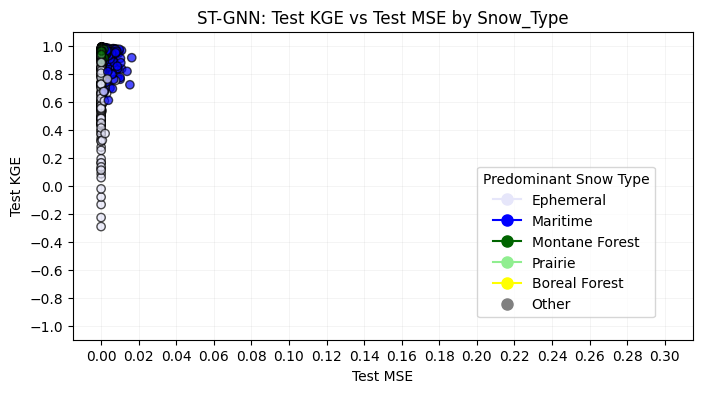

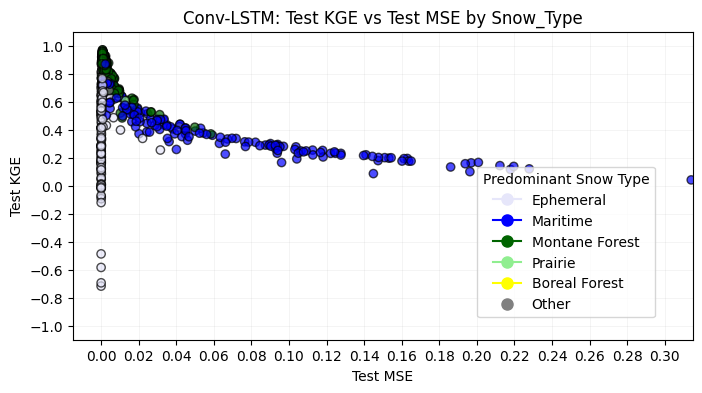

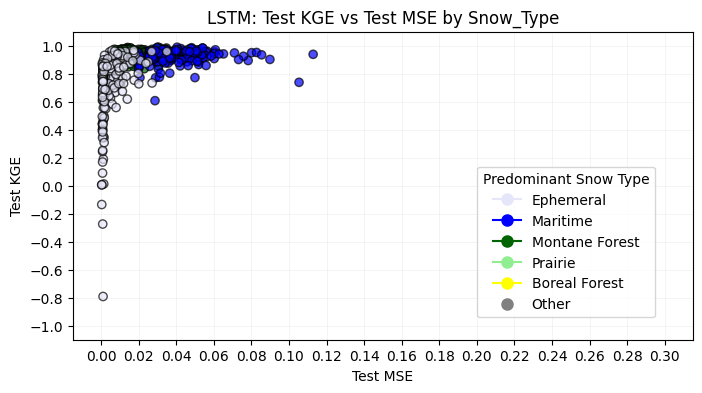

In [51]:
# All results 
y_var = "Test KGE"
x_var = "Test MSE"
ttl = f"{y_var} vs {x_var} by Snow_Type"

# ST-GNN
plot_scatter(df_stgnn, x_var, y_var, color_map=color_map_snow, model_name=STGNN, col="Predominant_Snow", title = ttl,
             other=True, min_val_x = 0, max_val_x=0.3, tick_gap_x=0.02,
             min_val_y = -1, max_val_y=1, tick_gap_y=0.2)

# Conv-LSTM
plot_scatter(df_convlstm, x_var, y_var, color_map=color_map_snow, model_name=CONV, col="Predominant_Snow", title = ttl,
             other=True, min_val_x = 0, max_val_x=0.3, tick_gap_x=0.02,
             min_val_y = -1, max_val_y=1, tick_gap_y=0.2)

# LSTM
plot_scatter(df_exp5, x_var, y_var, color_map=color_map_snow, model_name=LSTM, col="Predominant_Snow", title = ttl,
             other=True, min_val_x = 0, max_val_x=0.3, tick_gap_x=0.02,
             min_val_y = -1, max_val_y=1, tick_gap_y=0.2)

Set group_by and plot ST-GNN boxplot by predominant snow type.

In [21]:
df_stgnn_mme = df_stgnn[
    (df_stgnn["Predominant_Snow"] != "Boreal Forest") &
    (df_stgnn["Predominant_Snow"] != "Prairie") &
    (df_stgnn["Predominant_Snow"].notna())
].copy()
df_stgnn_mm = df_stgnn_mme[
    (df_stgnn_mme["Predominant_Snow"] != "Ephemeral")
].copy()

df_convlstm_mme = df_convlstm[
    (df_convlstm["Predominant_Snow"] != "Boreal Forest") &
    (df_convlstm["Predominant_Snow"] != "Prairie") &
    (df_convlstm["Predominant_Snow"].notna())
].copy()
df_convlstm_mm = df_convlstm_mme[
    (df_convlstm_mme["Predominant_Snow"] != "Ephemeral")
].copy()

df_exp5_mm = df_exp5[
    (df_exp5["Predominant_Snow"] != "Ephemeral") &
    (df_convlstm["Predominant_Snow"].notna())
].copy()

color_map_mme = extract_subdict(color_map_snow, ["Montane Forest", "Maritime", "Ephemeral"])
color_map_mm = extract_subdict(color_map_snow, ["Montane Forest", "Maritime"])

/var/folders/p8/c40n2f_55jjcmk252xr9d5mm0000gn/T/ipykernel_62996/501198209.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_exp5_mm = df_exp5[


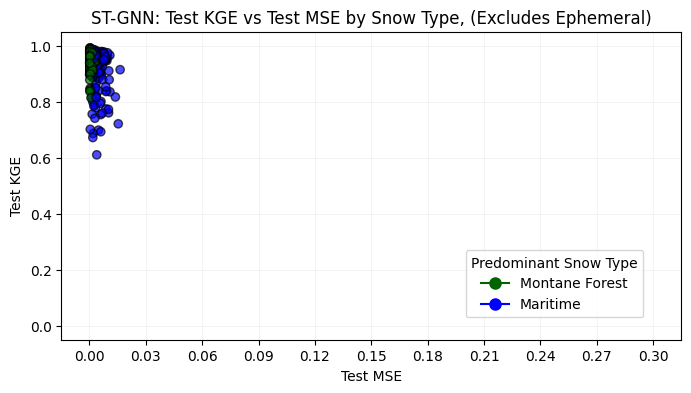

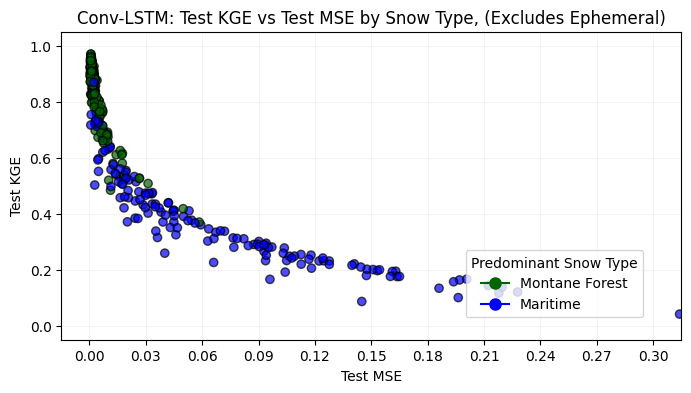

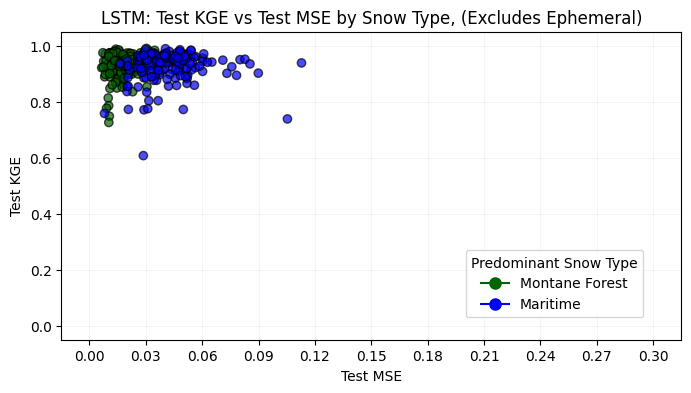

In [22]:
y_var = "Test KGE"
x_var = "Test MSE"
ttl = f"{y_var} vs {x_var} by Snow Type, (Excludes Ephemeral)"

#STGNN
plot_scatter(df_stgnn_mm, x_var, y_var, color_map=color_map_mm, model_name=STGNN, col="Predominant_Snow", title=ttl,
            min_val_x = 0, max_val_x=0.3, tick_gap_x=0.03,
             min_val_y = 0, max_val_y=1, tick_gap_y=0.2)

#Conv-LSTM
plot_scatter(df_convlstm_mm, x_var, y_var, color_map=color_map_mm, model_name=CONV, col="Predominant_Snow", title=ttl,
            min_val_x = 0, max_val_x=0.3, tick_gap_x=0.03,
             min_val_y = 0, max_val_y=1, tick_gap_y=0.2)

#LSTM
plot_scatter(df_exp5_mm, x_var, y_var, color_map=color_map_mm, model_name=LSTM, col="Predominant_Snow", title=ttl, 
            min_val_x = 0, max_val_x=0.3, tick_gap_x=0.03,
             min_val_y = 0, max_val_y=1, tick_gap_y=0.2)


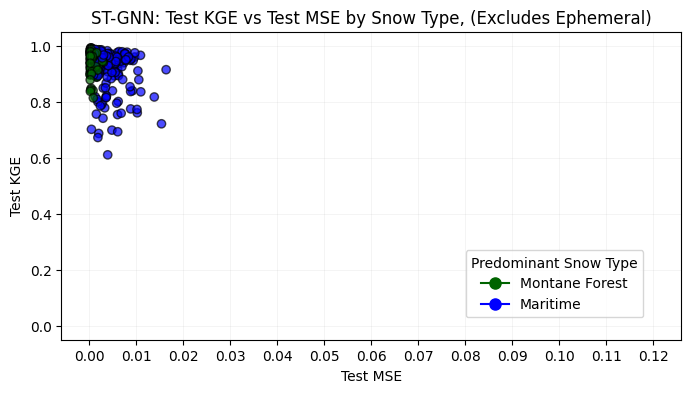

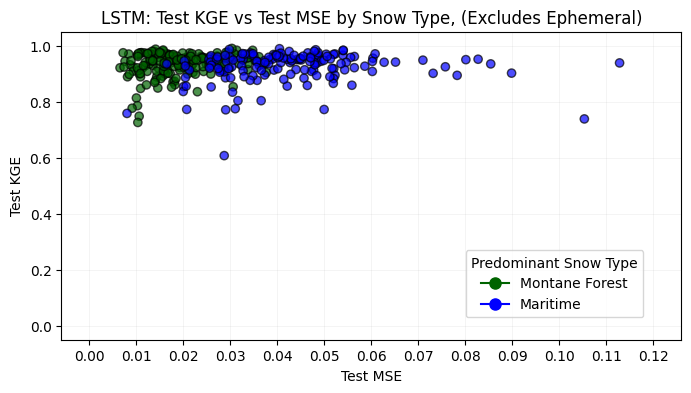

In [23]:
y_var = "Test KGE"
x_var = "Test MSE"
ttl = f"{y_var} vs {x_var} by Snow Type, (Excludes Ephemeral)"

#STGNN
plot_scatter(df_stgnn_mm, x_var, y_var, color_map=color_map_mm, model_name=STGNN, col="Predominant_Snow", title=ttl,
            min_val_x = 0, max_val_x=0.12, tick_gap_x=0.01,
             min_val_y = 0, max_val_y=1, tick_gap_y=0.2)

#LSTM
plot_scatter(df_exp5_mm, x_var, y_var, color_map=color_map_mm, model_name=LSTM, col="Predominant_Snow", title=ttl, 
            min_val_x = 0, max_val_x=0.12, tick_gap_x=0.01,
             min_val_y = 0, max_val_y=1, tick_gap_y=0.2)


## Step 4: Test KGE box plots by snow types

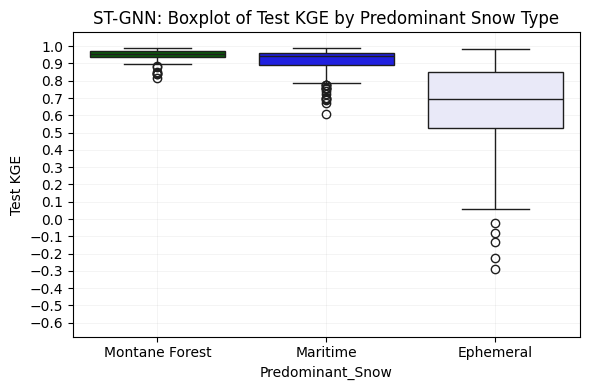

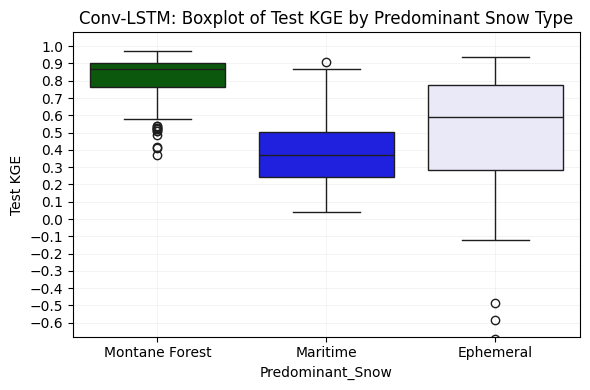

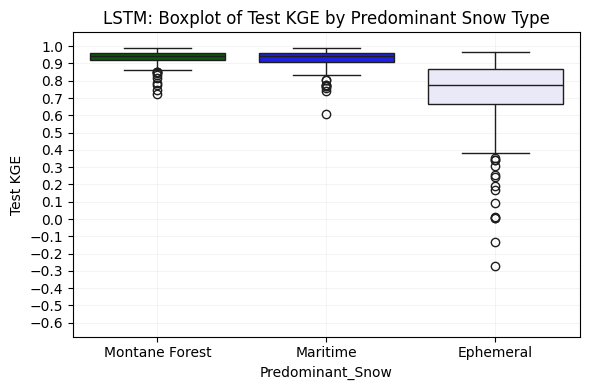

In [24]:
group_by = "Predominant_Snow"
param = "Test KGE"
ttl = f"Boxplot of {param} by Predominant Snow Type"

# STGNN
stgnn_data = plot_boxplot_by_group(df_stgnn_mme, parameter=param, title= ttl, model_name=STGNN, groupby_column = group_by, color_map = color_map_mme,
                                min_val_y = -0.6, max_val_y=1, tick_gap_y=0.1)

# CONV
conv_data = plot_boxplot_by_group(df_convlstm_mme, parameter=param, title= ttl, model_name=CONV, groupby_column = group_by, color_map = color_map_mme, 
                                 min_val_y = -0.6, max_val_y=1, tick_gap_y=0.1)

# LSTM
lstm_data = plot_boxplot_by_group(df_exp5, parameter=param, title= ttl, model_name=LSTM, groupby_column = group_by, color_map = color_map_mme, 
                                 min_val_y = -0.6, max_val_y=1, tick_gap_y=0.1)


In [25]:
print(f"P-values {STGNN} :{pairwise_welch_t_test(stgnn_data)}")
print(f"P-values {CONV} :{pairwise_welch_t_test(conv_data)}")
print(f"P-values {LSTM} :{pairwise_welch_t_test(lstm_data)}")

P-values ST-GNN :      Group1          Group2       P-Value
0  Ephemeral        Maritime  1.060934e-28
1  Ephemeral  Montane Forest  5.486956e-36
2   Maritime  Montane Forest  1.479783e-09
P-values Conv-LSTM :      Group1          Group2       P-Value
0  Ephemeral        Maritime  5.301484e-05
1  Ephemeral  Montane Forest  8.350833e-26
2   Maritime  Montane Forest  7.167485e-69
P-values LSTM :      Group1          Group2       P-Value
0  Ephemeral        Maritime  1.560043e-22
1  Ephemeral  Montane Forest  2.272926e-24
2   Maritime  Montane Forest  6.241674e-02


Repeat boxplot by snow type for comparison across models.

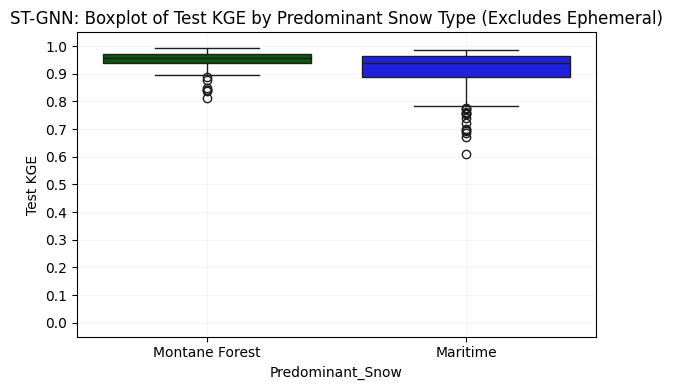

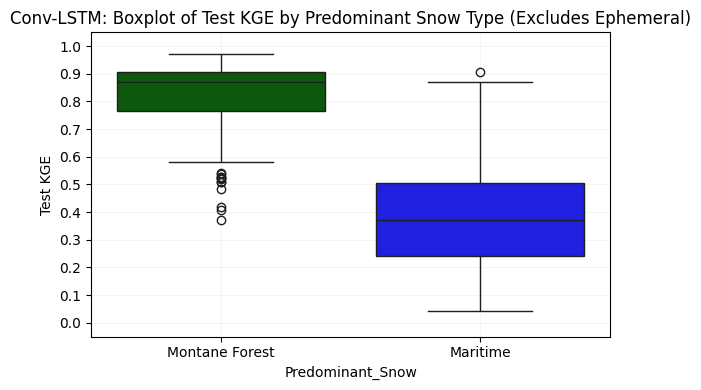

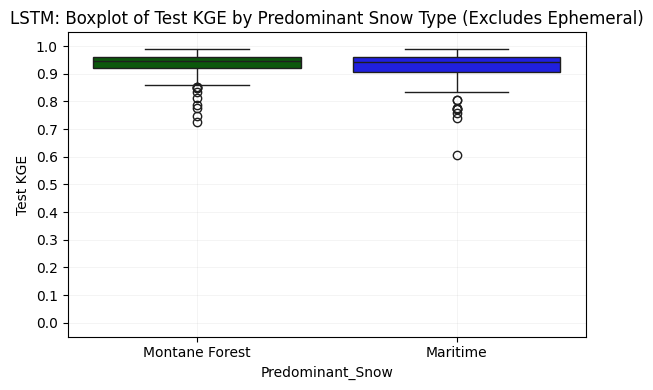

In [29]:
group_by = "Predominant_Snow"
param = "Test KGE"
ttl = f"Boxplot of {param} by Predominant Snow Type (Excludes Ephemeral)"

# STGNN
stgnn_data = plot_boxplot_by_group(df_stgnn_mm, parameter=param, title= ttl, model_name=STGNN, groupby_column = group_by, color_map = color_map_mm,
                                min_val_y = -0, max_val_y=1, tick_gap_y=0.1)

# CONV
conv_data = plot_boxplot_by_group(df_convlstm_mm, parameter=param, title= ttl, model_name=CONV, groupby_column = group_by, color_map = color_map_mm, 
                                 min_val_y = -0, max_val_y=1, tick_gap_y=0.1)

# LSTM
lstm_data = plot_boxplot_by_group(df_exp5_mm, parameter=param, title= ttl, model_name=LSTM, groupby_column = group_by, color_map = color_map_mm, 
                                 min_val_y = -0, max_val_y=1, tick_gap_y=0.1)


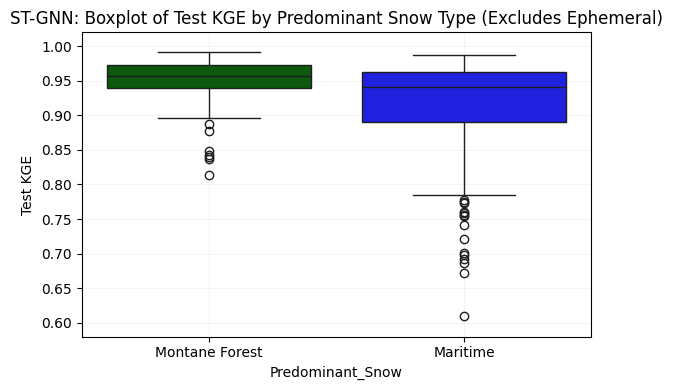

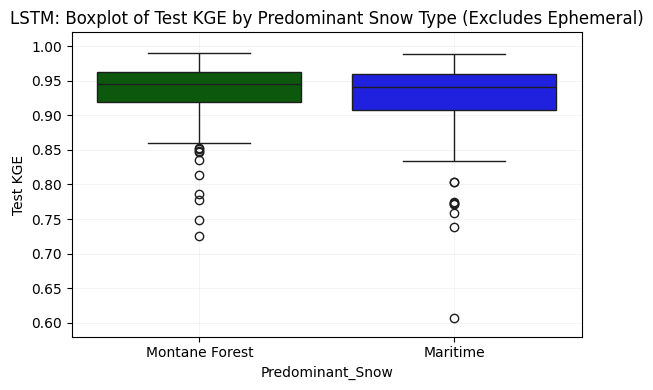

In [30]:
group_by = "Predominant_Snow"
param = "Test KGE"
ttl = f"Boxplot of {param} by Predominant Snow Type (Excludes Ephemeral)"

# STGNN
stgnn_data = plot_boxplot_by_group(df_stgnn_mm, parameter=param, title= ttl, model_name=STGNN, groupby_column = group_by, color_map = color_map_mm,
                                min_val_y = 0.6, max_val_y=1, tick_gap_y=0.05)

# LSTM
lstm_data = plot_boxplot_by_group(df_exp5_mm, parameter=param, title= ttl, model_name=LSTM, groupby_column = group_by, color_map = color_map_mm, 
                                 min_val_y = 0.6, max_val_y=1, tick_gap_y=0.05)


## Step 5: Test MSE box plots by snow types

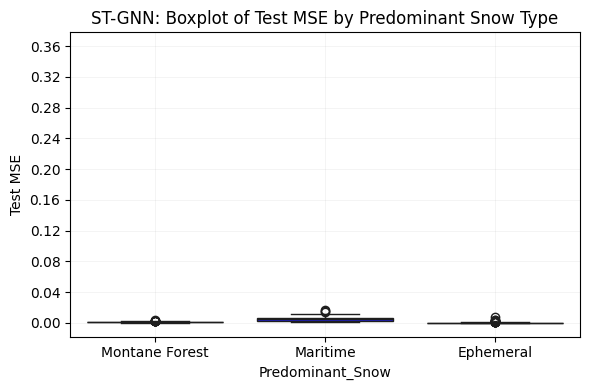

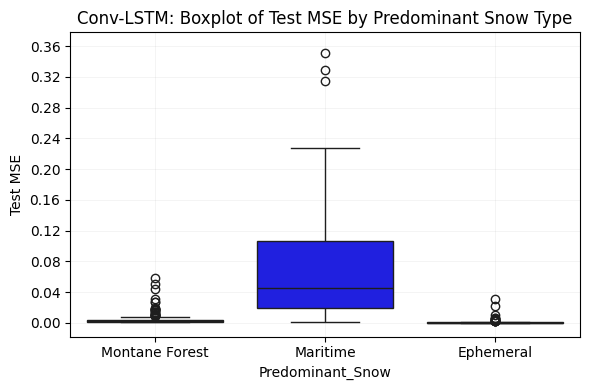

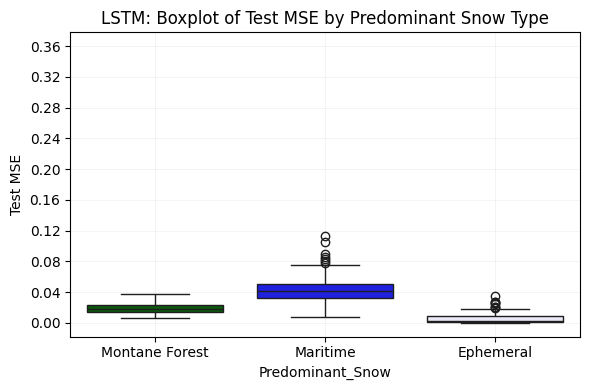

In [27]:
group_by = "Predominant_Snow"
param = "Test MSE"
ttl = f"Boxplot of {param} by Predominant Snow Type"

# STGNN
stgnn_data = plot_boxplot_by_group(df_stgnn_mme, parameter=param, title= ttl, model_name=STGNN, groupby_column = group_by, color_map = color_map_mme,
                                min_val_y = 0, max_val_y=0.36, tick_gap_y=0.04)

# CONV
conv_data = plot_boxplot_by_group(df_convlstm_mme, parameter=param, title= ttl, model_name=CONV, groupby_column = group_by, color_map = color_map_mme, 
                                 min_val_y = 0, max_val_y=0.36, tick_gap_y=0.04)

# LSTM
lstm_data = plot_boxplot_by_group(df_exp5, parameter=param, title= ttl, model_name=LSTM, groupby_column = group_by, color_map = color_map_mme, 
                                 min_val_y = 0, max_val_y=0.36, tick_gap_y=0.04)


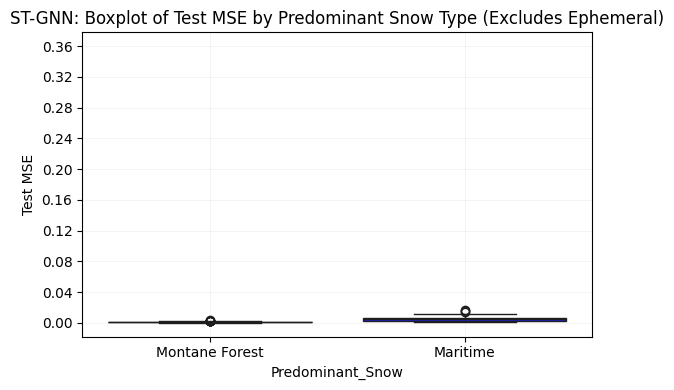

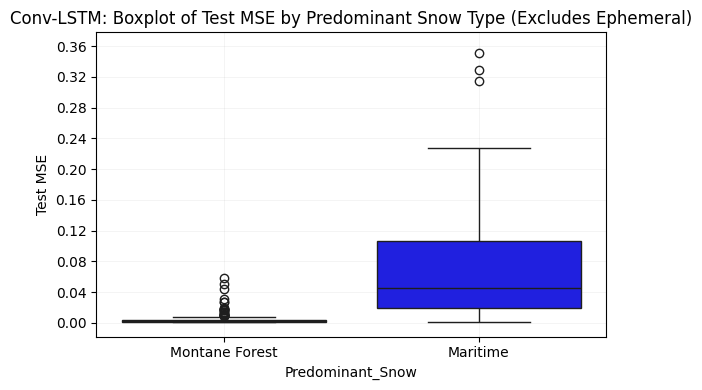

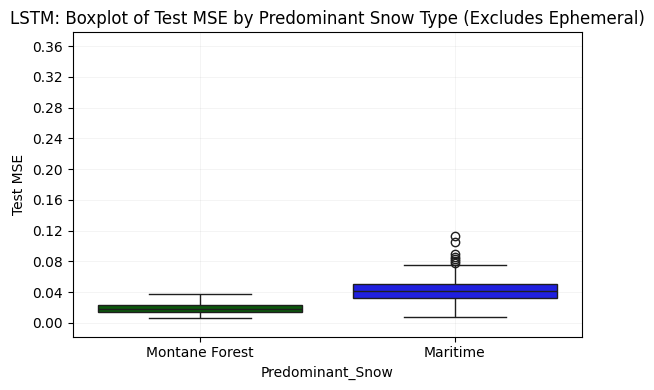

In [28]:
group_by = "Predominant_Snow"
param = "Test MSE"
ttl = f"Boxplot of {param} by Predominant Snow Type (Excludes Ephemeral)"

# STGNN
stgnn_data = plot_boxplot_by_group(df_stgnn_mm, parameter=param, title= ttl, model_name=STGNN, groupby_column = group_by, color_map = color_map_mm,
                                min_val_y = 0, max_val_y=0.36, tick_gap_y=0.04)

# CONV
conv_data = plot_boxplot_by_group(df_convlstm_mm, parameter=param, title= ttl, model_name=CONV, groupby_column = group_by, color_map = color_map_mm, 
                                 min_val_y = 0, max_val_y=0.36, tick_gap_y=0.04)

# LSTM
lstm_data = plot_boxplot_by_group(df_exp5_mm, parameter=param, title= ttl, model_name=LSTM, groupby_column = group_by, color_map = color_map_mm, 
                                 min_val_y = 0, max_val_y=0.36, tick_gap_y=0.04)


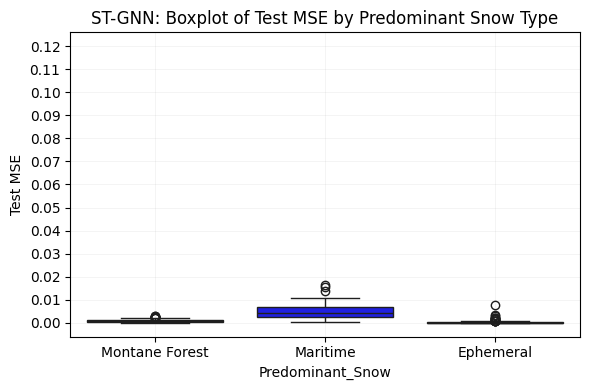

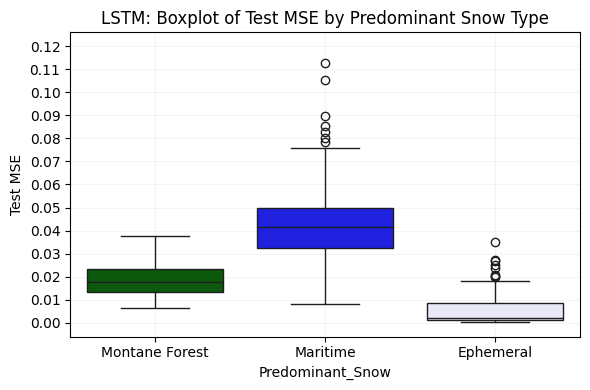

In [33]:
group_by = "Predominant_Snow"
param = "Test MSE"
ttl = f"Boxplot of {param} by Predominant Snow Type"

# STGNN
stgnn_data = plot_boxplot_by_group(df_stgnn_mme, parameter=param, title= ttl, model_name=STGNN, groupby_column = group_by, color_map = color_map_mme,
                                min_val_y = 0, max_val_y=0.12, tick_gap_y=0.01)

# LSTM
lstm_data = plot_boxplot_by_group(df_exp5, parameter=param, title= ttl, model_name=LSTM, groupby_column = group_by, color_map = color_map_mme, 
                                 min_val_y = 0, max_val_y=0.12, tick_gap_y=0.01)


## Step 6 – Examine by basin

Set parameter (Test KGE or Test MSE) and plot boxplots grouped by HUC8 basin.

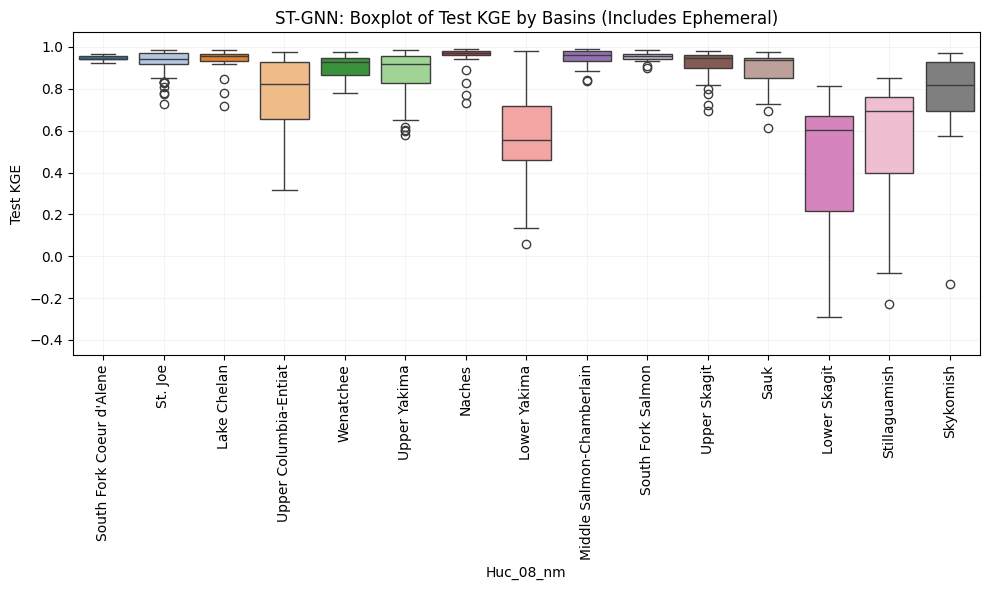

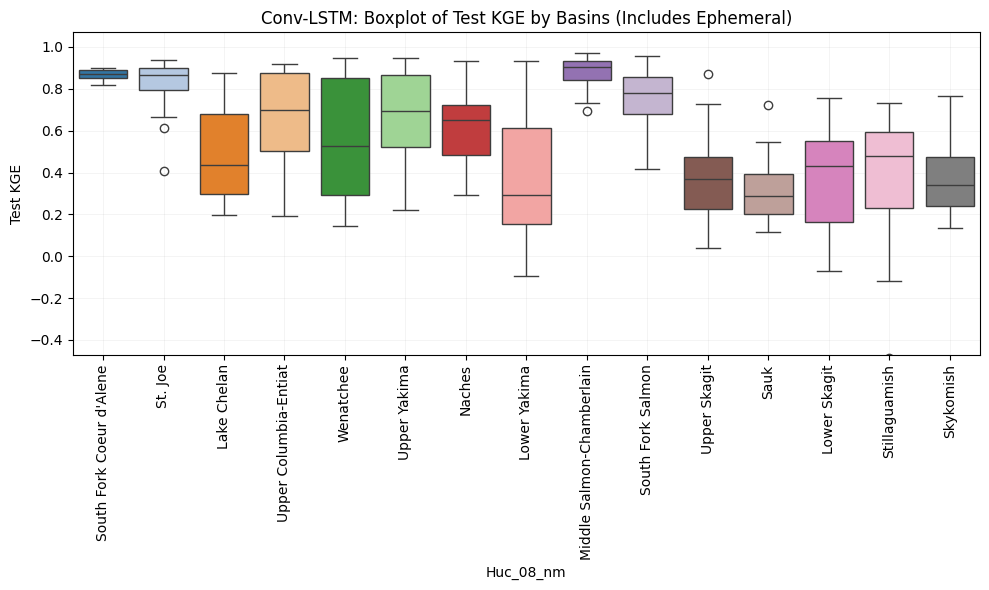

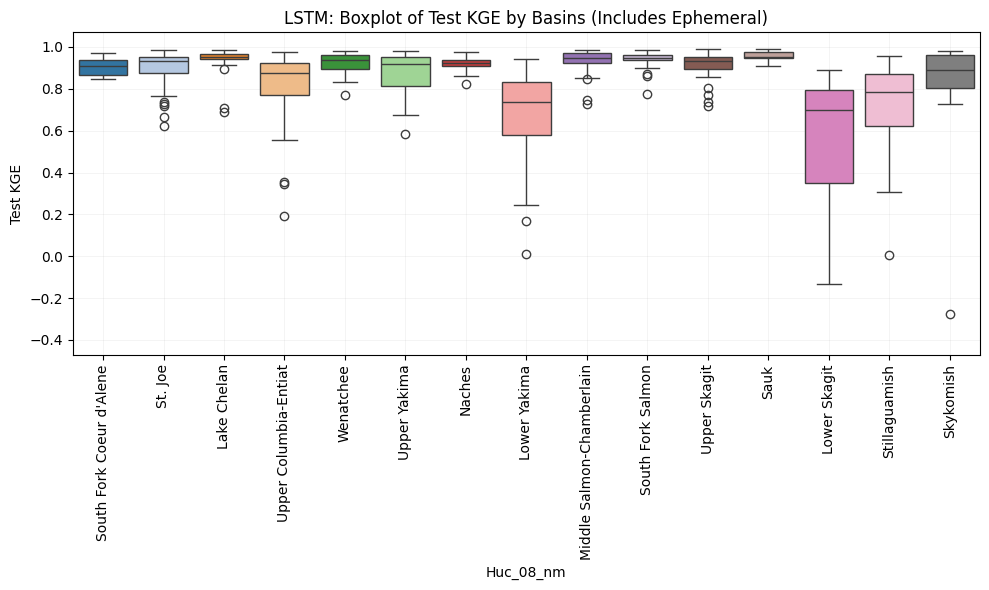

,count,median,mean,std
Huc_08_nm,,,,
Lake Chelan,28,0.953718,0.934970,0.069204
Lower Skagit,11,0.699016,0.544837,0.373362
Lower Yakima,71,0.737379,0.681662,0.198422
Middle Salmon-Chamberlain,51,0.949235,0.935284,0.051665
Naches,29,0.924779,0.921191,0.032365
Sauk,15,0.953703,0.956714,0.021876
Skykomish,21,0.889122,0.826498,0.264069
South Fork Coeur d'Alene,8,0.910776,0.906385,0.045755
South Fork Salmon,41,0.948486,0.941360,0.037154


In [41]:
parameter = "Test KGE"
group_by ="Huc_08_nm"
ttl = f"Boxplot of {parameter} by Basins (Includes Ephemeral)"
category_order=df_names['Huc_08_nm']
palette = dict(zip(category_order, sns.color_palette("tab20", n_colors=len(category_order))))

# STGNN
plot_boxplot_by_group(df_stgnn_mme, parameter=parameter, title=ttl, model_name=STGNN, groupby_column = group_by, color_map=palette, is_small=False,
                                category_order=category_order, trunc = True, min_val_y = -0.4, max_val_y=1, tick_gap_y=0.2)
# CONV
plot_boxplot_by_group(df_convlstm_mme, parameter=parameter, title=ttl, model_name=CONV, groupby_column = group_by, color_map=palette, is_small=False,
                                category_order=category_order, trunc = True, min_val_y = -0.4, max_val_y=1, tick_gap_y=0.2)
# LSTM
plot_boxplot_by_group(df_exp5, parameter=parameter, title=ttl, model_name=LSTM, groupby_column = group_by, color_map=palette, is_small=False,
                                category_order=category_order, trunc = True, min_val_y = -0.4, max_val_y=1, tick_gap_y=0.2)

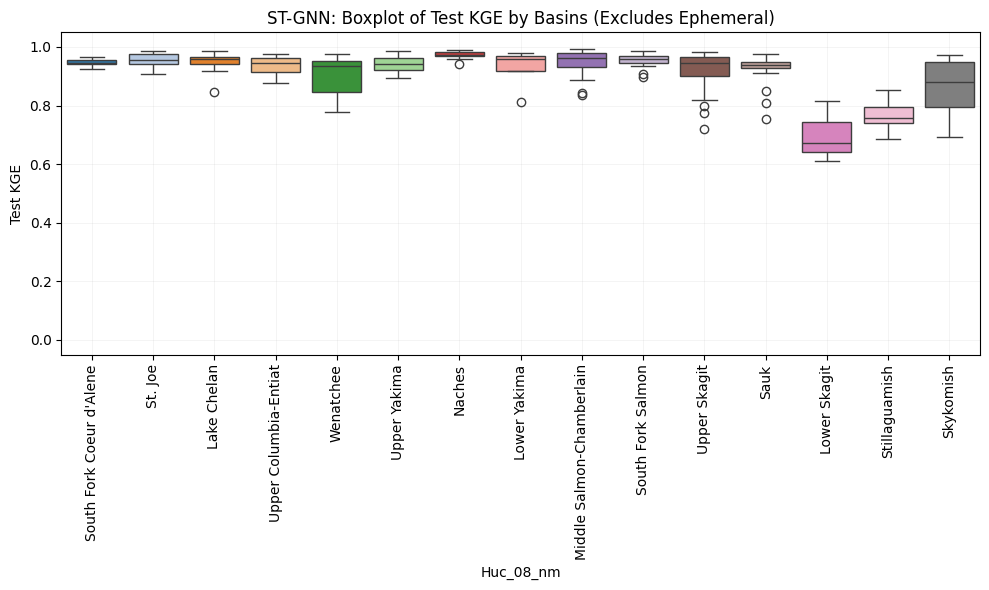

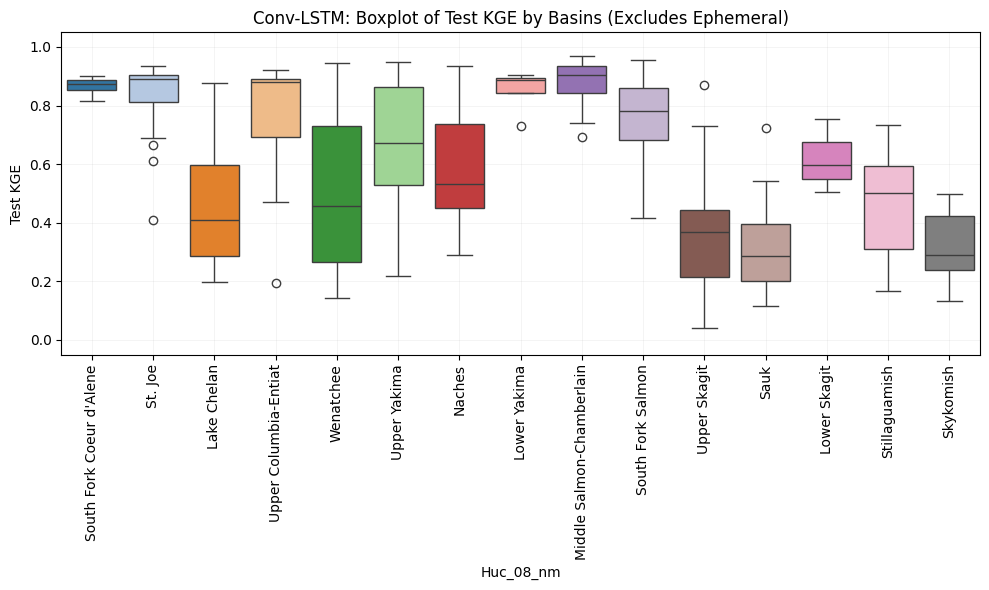

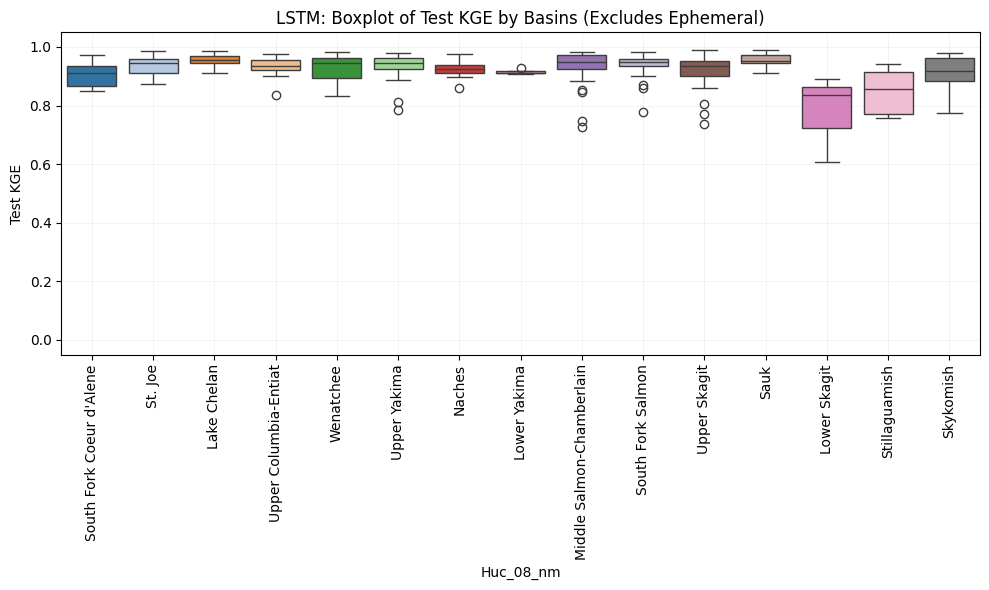

,count,median,mean,std
Huc_08_nm,,,,
Lake Chelan,23,0.955497,0.954874,0.017470
Lower Skagit,3,0.836492,0.777818,0.149831
Lower Yakima,4,0.912382,0.915192,0.007813
Middle Salmon-Chamberlain,50,0.950044,0.936521,0.051421
Naches,23,0.924779,0.924194,0.024351
Sauk,15,0.953703,0.956714,0.021876
Skykomish,15,0.918735,0.911423,0.062968
South Fork Coeur d'Alene,8,0.910776,0.906385,0.045755
South Fork Salmon,41,0.948486,0.941360,0.037154


In [42]:
parameter = "Test KGE"
group_by ="Huc_08_nm"
ttl = f"Boxplot of {parameter} by Basins (Excludes Ephemeral)"

# STGNN
plot_boxplot_by_group(df_stgnn_mm, parameter=parameter, title=ttl, model_name=STGNN, groupby_column = group_by, color_map=palette, is_small=False,
                                category_order=category_order, trunc = True, min_val_y = 0, max_val_y=1, tick_gap_y=0.2)
# CONV
plot_boxplot_by_group(df_convlstm_mm, parameter=parameter, title=ttl, model_name=CONV, groupby_column = group_by, color_map=palette, is_small=False,
                                category_order=category_order, trunc = True, min_val_y = 0, max_val_y=1, tick_gap_y=0.2)
# LSTM
plot_boxplot_by_group(df_exp5_mm, parameter=parameter, title=ttl, model_name=LSTM, groupby_column = group_by, color_map=palette, is_small=False,
                                category_order=category_order, trunc = True, min_val_y = 0, max_val_y=1, tick_gap_y=0.2)

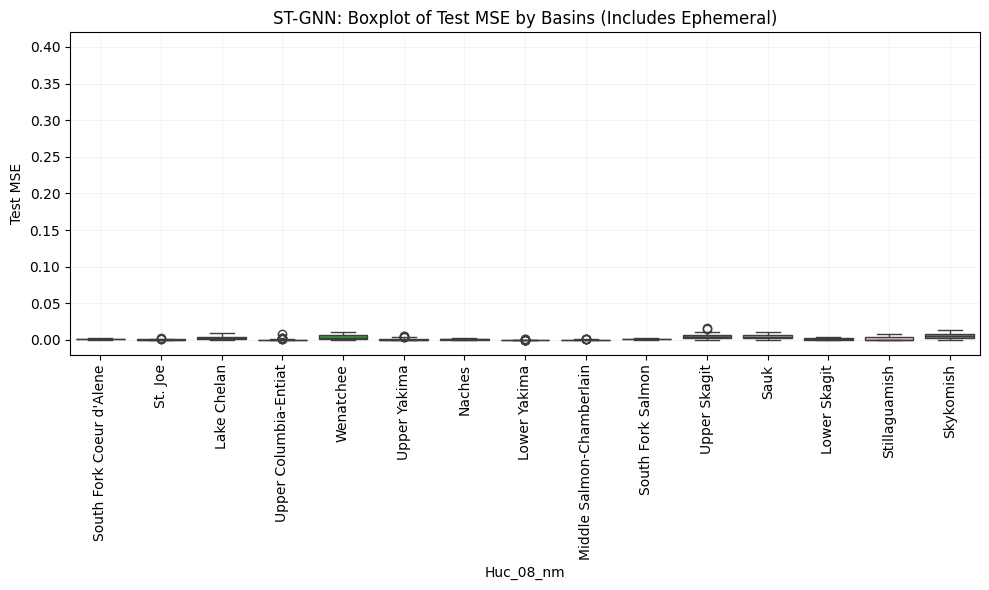

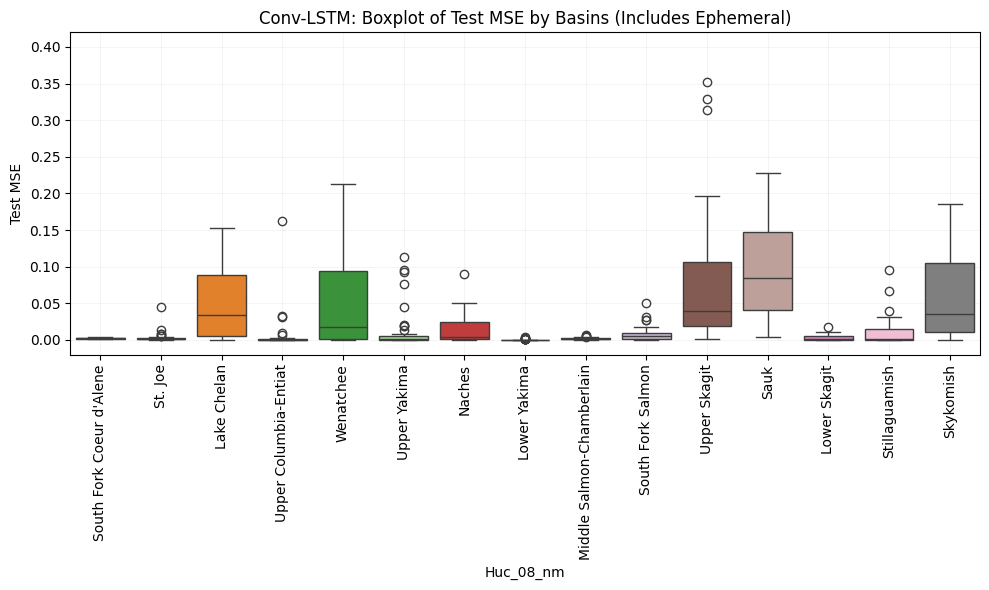

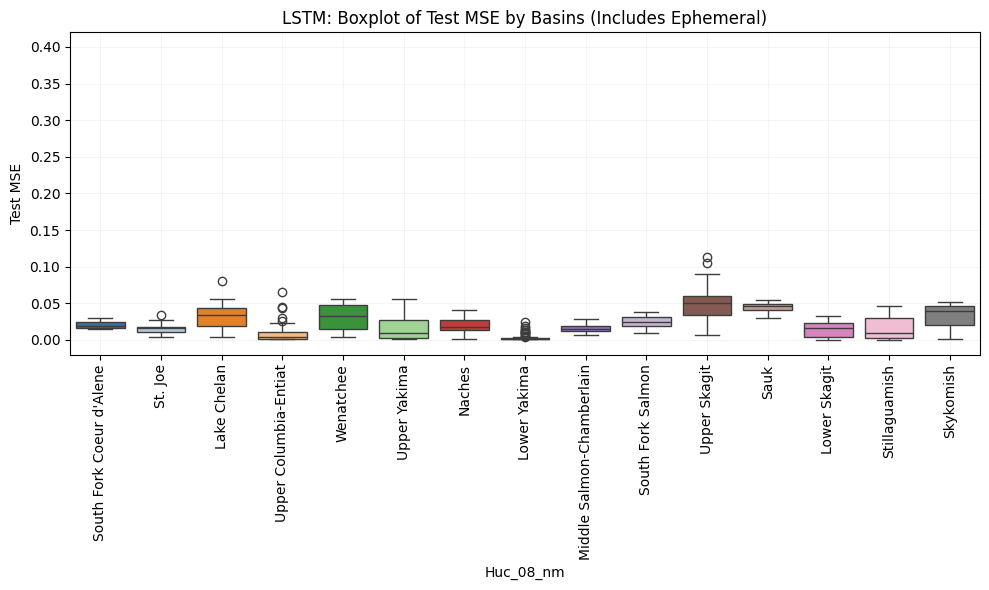

,count,median,mean,std
Huc_08_nm,,,,
Lake Chelan,28,0.034228,0.032233,0.017387
Lower Skagit,11,0.016923,0.015064,0.011777
Lower Yakima,71,0.001086,0.003145,0.004765
Middle Salmon-Chamberlain,51,0.015423,0.016092,0.005309
Naches,29,0.018201,0.020267,0.011484
Sauk,15,0.046934,0.044182,0.006799
Skykomish,21,0.039815,0.032783,0.015958
South Fork Coeur d'Alene,8,0.019017,0.020980,0.005764
South Fork Salmon,41,0.024172,0.025206,0.007945


In [43]:
parameter = "Test MSE"
group_by ="Huc_08_nm"
ttl = f"Boxplot of {parameter} by Basins (Includes Ephemeral)"

# STGNN
plot_boxplot_by_group(df_stgnn_mme, parameter=parameter, title=ttl, model_name=STGNN, groupby_column = group_by, color_map=palette, is_small=False,
                                category_order=category_order, trunc = True, min_val_y = 0, max_val_y=0.4, tick_gap_y=0.05)
# CONV
plot_boxplot_by_group(df_convlstm_mme, parameter=parameter, title=ttl, model_name=CONV, groupby_column = group_by, color_map=palette, is_small=False,
                                category_order=category_order, trunc = True, min_val_y = 0, max_val_y=0.4, tick_gap_y=0.05)
# LSTM
plot_boxplot_by_group(df_exp5, parameter=parameter, title=ttl, model_name=LSTM, groupby_column = group_by, color_map=palette, is_small=False,
                                category_order=category_order, trunc = True, min_val_y = 0, max_val_y=0.4, tick_gap_y=0.05)

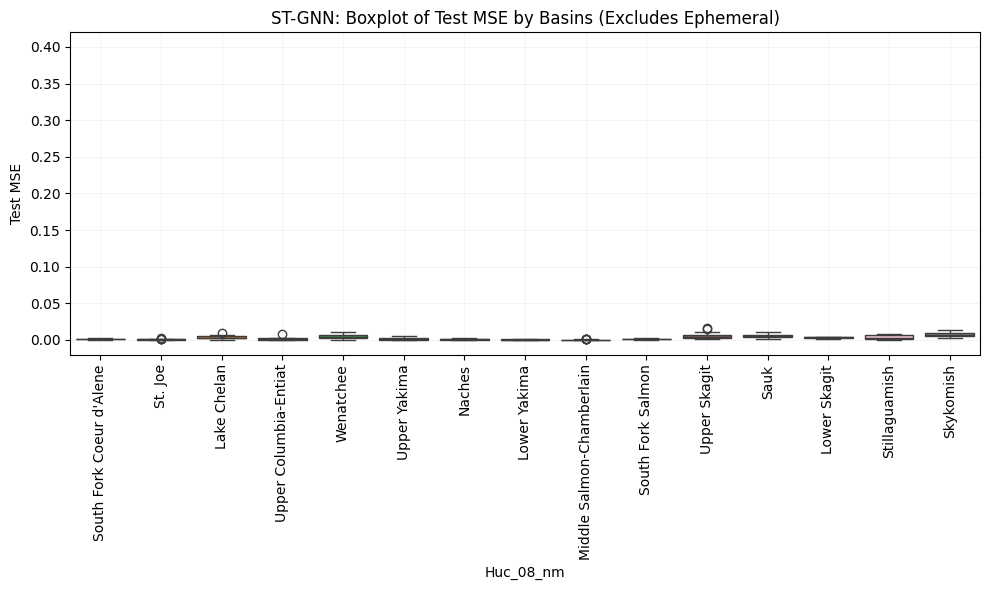

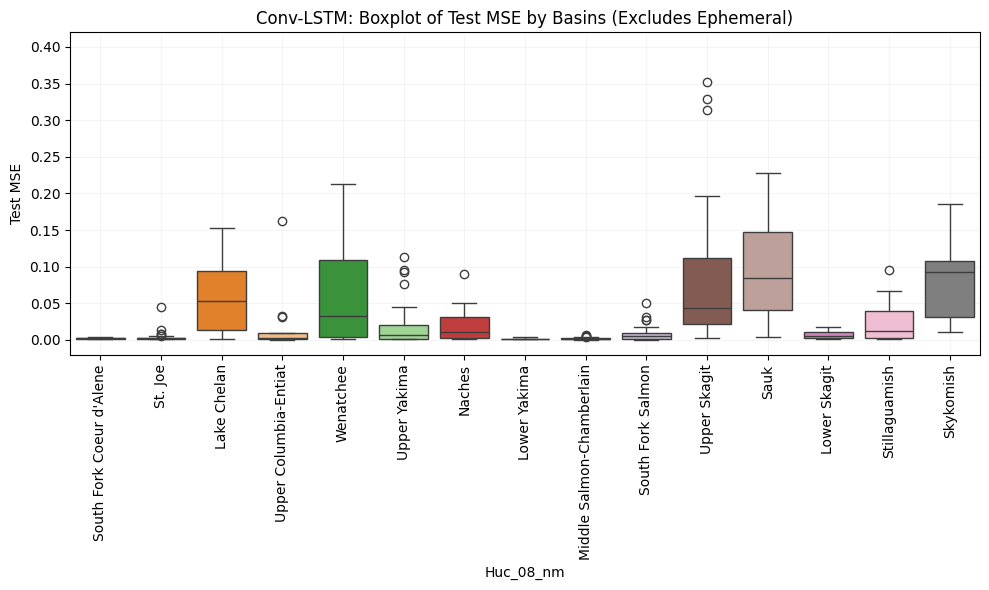

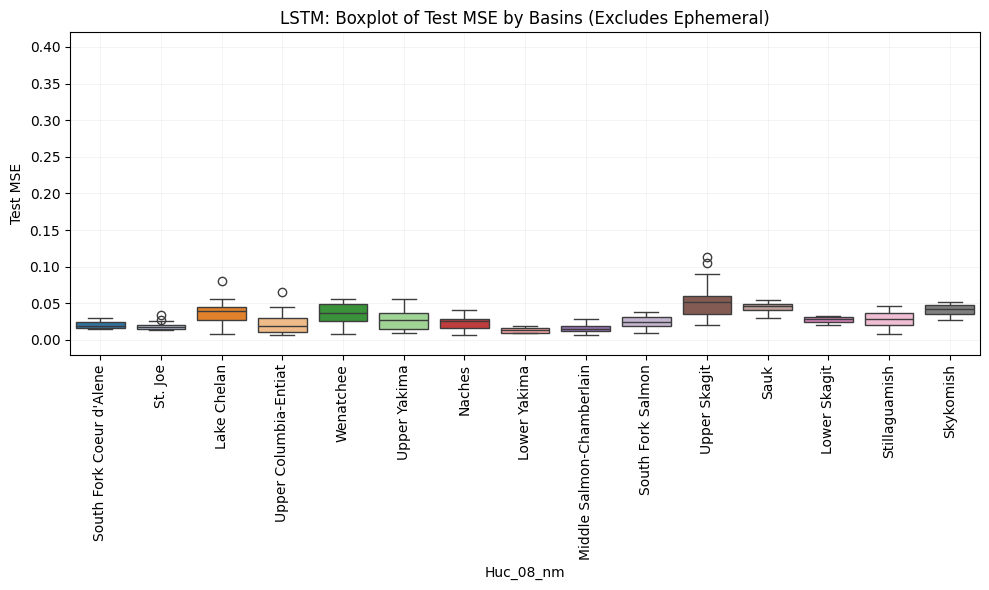

,count,median,mean,std
Huc_08_nm,,,,
Lake Chelan,23,0.039182,0.036764,0.015507
Lower Skagit,3,0.028690,0.027193,0.006605
Lower Yakima,4,0.013142,0.013707,0.004645
Middle Salmon-Chamberlain,50,0.015559,0.016245,0.005248
Naches,23,0.025780,0.024026,0.009389
Sauk,15,0.046934,0.044182,0.006799
Skykomish,15,0.042848,0.041360,0.008044
South Fork Coeur d'Alene,8,0.019017,0.020980,0.005764
South Fork Salmon,41,0.024172,0.025206,0.007945


In [45]:
parameter = "Test MSE"
group_by ="Huc_08_nm"
ttl = f"Boxplot of {parameter} by Basins (Excludes Ephemeral)"

# STGNN
plot_boxplot_by_group(df_stgnn_mm, parameter=parameter, title=ttl, model_name=STGNN, groupby_column = group_by, color_map=palette, is_small=False,
                                category_order=category_order, trunc = True, min_val_y = 0, max_val_y=0.4, tick_gap_y=0.05)
# CONV
plot_boxplot_by_group(df_convlstm_mm, parameter=parameter, title=ttl, model_name=CONV, groupby_column = group_by, color_map=palette, is_small=False,
                                category_order=category_order, trunc = True, min_val_y = 0, max_val_y=0.4, tick_gap_y=0.05)
# LSTM
plot_boxplot_by_group(df_exp5_mm, parameter=parameter, title=ttl, model_name=LSTM, groupby_column = group_by, color_map=palette, is_small=False,
                                category_order=category_order, trunc = True, min_val_y = 0, max_val_y=0.4, tick_gap_y=0.05)

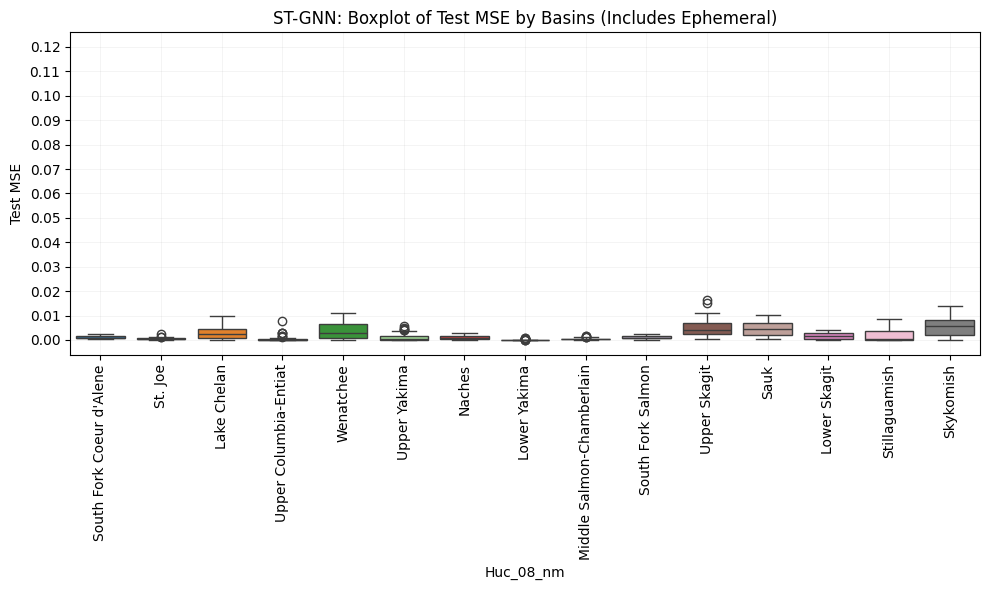

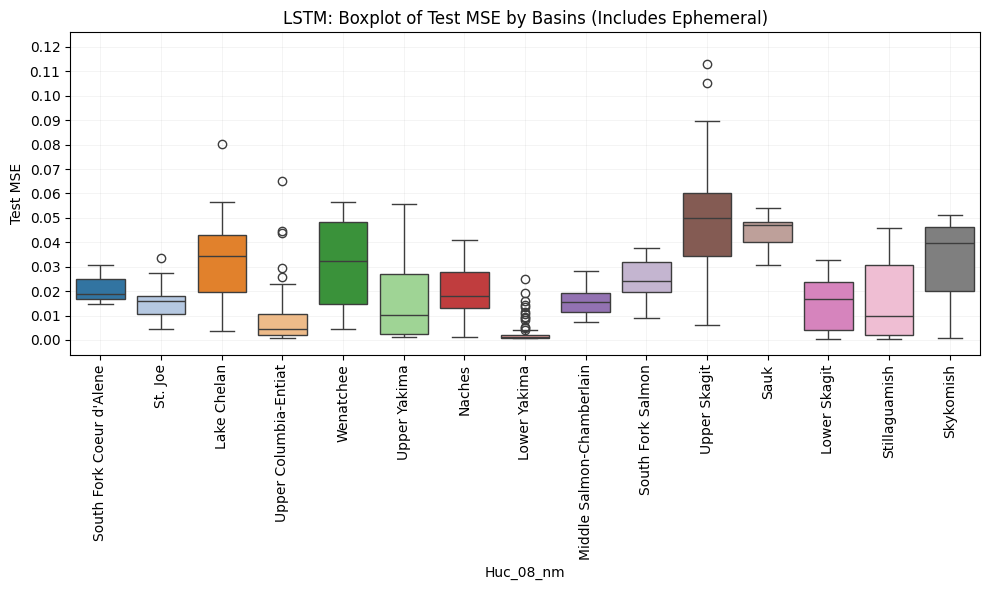

,count,median,mean,std
Huc_08_nm,,,,
Lake Chelan,28,0.034228,0.032233,0.017387
Lower Skagit,11,0.016923,0.015064,0.011777
Lower Yakima,71,0.001086,0.003145,0.004765
Middle Salmon-Chamberlain,51,0.015423,0.016092,0.005309
Naches,29,0.018201,0.020267,0.011484
Sauk,15,0.046934,0.044182,0.006799
Skykomish,21,0.039815,0.032783,0.015958
South Fork Coeur d'Alene,8,0.019017,0.020980,0.005764
South Fork Salmon,41,0.024172,0.025206,0.007945


In [47]:
parameter = "Test MSE"
group_by ="Huc_08_nm"
ttl = f"Boxplot of {parameter} by Basins (Includes Ephemeral)"

# STGNN
plot_boxplot_by_group(df_stgnn_mme, parameter=parameter, title=ttl, model_name=STGNN, groupby_column = group_by, color_map=palette, is_small=False,
                                category_order=category_order, trunc = True, min_val_y = 0, max_val_y=0.12, tick_gap_y=0.01)
# LSTM
plot_boxplot_by_group(df_exp5, parameter=parameter, title=ttl, model_name=LSTM, groupby_column = group_by, color_map=palette, is_small=False,
                                category_order=category_order, trunc = True, min_val_y = 0, max_val_y=0.12, tick_gap_y=0.01)

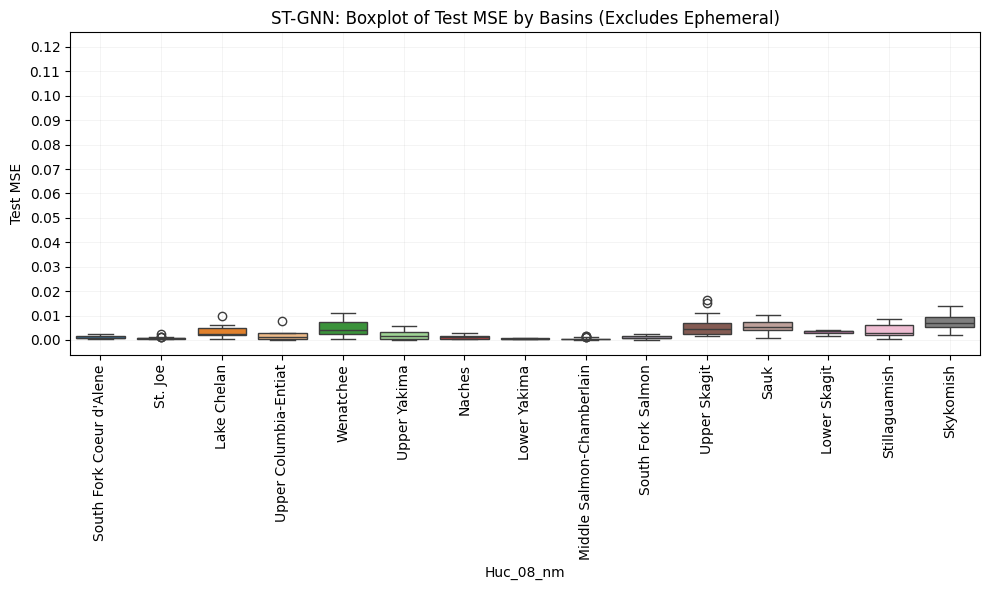

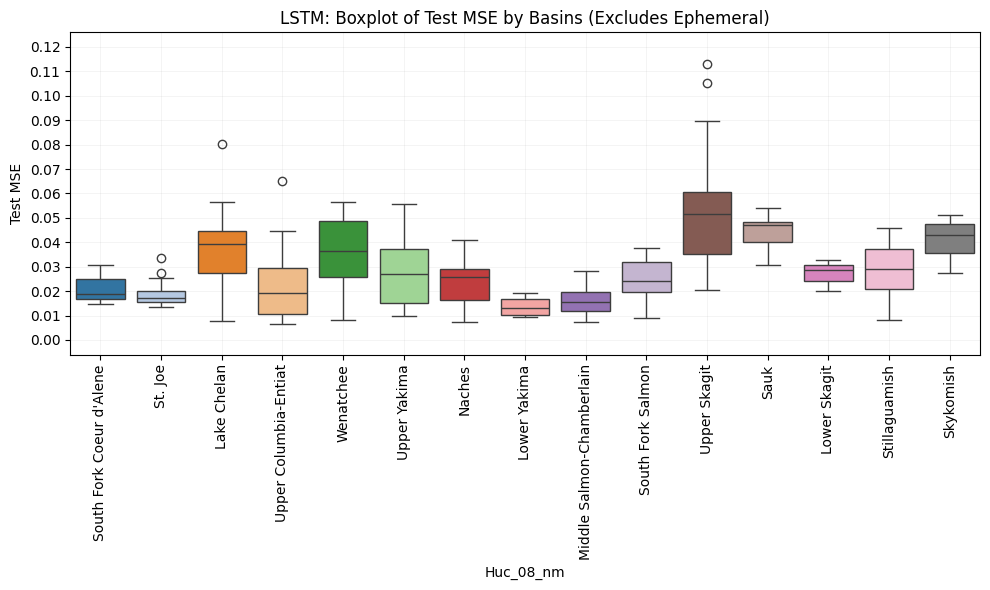

,count,median,mean,std
Huc_08_nm,,,,
Lake Chelan,23,0.039182,0.036764,0.015507
Lower Skagit,3,0.028690,0.027193,0.006605
Lower Yakima,4,0.013142,0.013707,0.004645
Middle Salmon-Chamberlain,50,0.015559,0.016245,0.005248
Naches,23,0.025780,0.024026,0.009389
Sauk,15,0.046934,0.044182,0.006799
Skykomish,15,0.042848,0.041360,0.008044
South Fork Coeur d'Alene,8,0.019017,0.020980,0.005764
South Fork Salmon,41,0.024172,0.025206,0.007945


In [48]:
parameter = "Test MSE"
group_by ="Huc_08_nm"
ttl = f"Boxplot of {parameter} by Basins (Excludes Ephemeral)"

# STGNN
plot_boxplot_by_group(df_stgnn_mm, parameter=parameter, title=ttl, model_name=STGNN, groupby_column = group_by, color_map=palette, is_small=False,
                                category_order=category_order, trunc = True, min_val_y = 0, max_val_y=0.12, tick_gap_y=0.01)
# LSTM
plot_boxplot_by_group(df_exp5_mm, parameter=parameter, title=ttl, model_name=LSTM, groupby_column = group_by, color_map=palette, is_small=False,
                                category_order=category_order, trunc = True, min_val_y = 0, max_val_y=0.12, tick_gap_y=0.01)

Set x_var to mean_elevation and plot scatter (e.g. elevation vs Test KGE), colored by snow type.

# Step 7 Examine by Elevation 

Scatter by mean elevation (second model or metric).

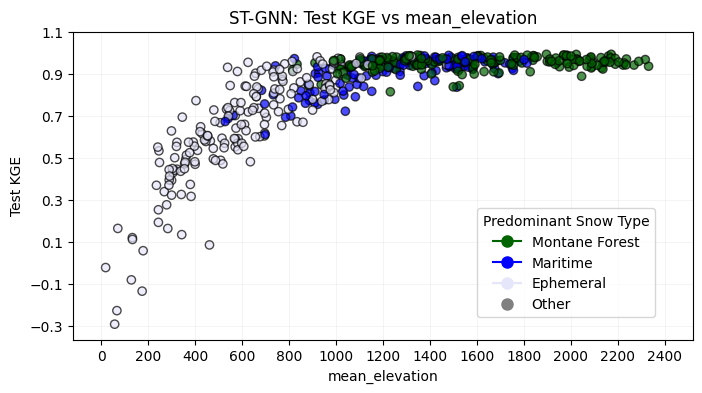

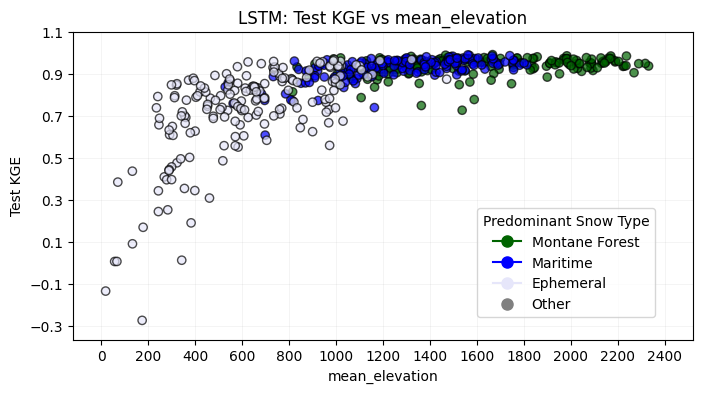

In [ ]:
x_var = "mean_elevation"
y_var = "Test KGE"
ttl = f"{y_var} vs {x_var} (Includes Ephemeral)"

# STGNN
plot_scatter(df_stgnn_mme, x_var, y_var, color_map=color_map_mme, model_name=STGNN, col="Predominant_Snow", title = ttl,
             other=True, min_val_x = 0, max_val_x=2400, tick_gap_x=200,
             min_val_y = -0.3, max_val_y=1, tick_gap_y=0.2)

# LSTM
plot_scatter(df_exp5, x_var, y_var, color_map=color_map_mme, model_name=LSTM, col="Predominant_Snow", title = ttl,
             other=True, min_val_x = 0, max_val_x=2400, tick_gap_x=200,
             min_val_y = -0.3, max_val_y=1, tick_gap_y=0.2)

*(Optional scratch cell.)*

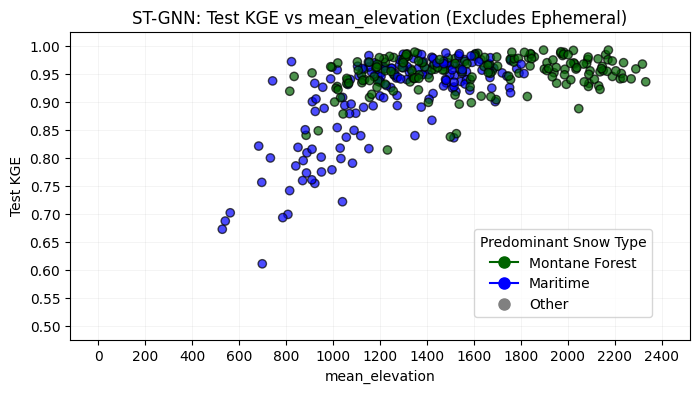

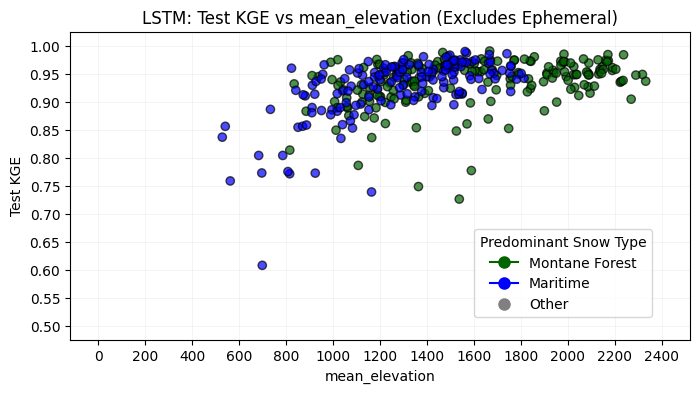

In [56]:
x_var = "mean_elevation"
y_var = "Test KGE"
ttl = f"{y_var} vs {x_var} (Excludes Ephemeral)"

# STGNN
plot_scatter(df_stgnn_mm, x_var, y_var, color_map=color_map_mm, model_name=STGNN, col="Predominant_Snow", title = ttl,
             other=True, min_val_x = 0, max_val_x=2400, tick_gap_x=200,
             min_val_y = 0.5, max_val_y=1, tick_gap_y=0.05)

# LSTM
plot_scatter(df_exp5_mm, x_var, y_var, color_map=color_map_mm, model_name=LSTM, col="Predominant_Snow", title = ttl,
             other=True, min_val_x = 0, max_val_x=2400, tick_gap_x=200,
             min_val_y = 0.5, max_val_y=1, tick_gap_y=0.05)